In [5]:
# imports
import os
import cv2
import torch
import joblib
import numpy as np
import pandas as pd
import torch
import torch.nn as nn

from PIL import Image
from tqdm import tqdm

from sklearn.metrics.pairwise import cosine_similarity

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
)

from retinaface import RetinaFace

from insightface.app import FaceAnalysis

In [6]:
TINYFACE_CSV = "/Users/admin/Desktop/reliable_rejection_under_degradation/verification_mlp/verification_mlp_multilayer/mlp_multilayer_fullExtendedVersion/tinyface_verification_dataset.csv"

In [7]:
# loading the model
class MLPExperiment(nn.Module):

    def __init__(self):

        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(3, 32),
            nn.ReLU(),
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Linear(16, 8),
            nn.ReLU(),
            nn.Linear(8, 2),
        )

    def forward(self, x):

        return self.network(x)

In [8]:
model = MLPExperiment()

model.load_state_dict(
    torch.load("mlp_finalExp_model.pth", map_location=torch.device("cpu"))
)

model.eval()

print("MLP Loaded")

MLP Loaded


In [9]:
# loading the scaler
scaler = joblib.load("mlp_scaler_finalExp.pkl")

print("Scaler Loaded")

Scaler Loaded


In [10]:
# evaluation function
def evaluate_dataset(csv_file):

    df = pd.read_csv(csv_file)

    X = df[["quality_score", "best_similarity", "margin"]]

    y_true = df["label"]

    X_scaled = scaler.transform(X)

    X_tensor = torch.tensor(X_scaled, dtype=torch.float32)

    with torch.no_grad():

        outputs = model(X_tensor)
        probs=torch.softmax(outputs, dim=1)
        print(probs[:20])
        y_pred=torch.argmax(outputs, dim=1).numpy()

    accuracy = accuracy_score(y_true, y_pred)

    precision = precision_score(y_true, y_pred, zero_division=0)

    recall = recall_score(y_true, y_pred, zero_division=0)

    f1 = f1_score(y_true, y_pred, zero_division=0)

    cm = confusion_matrix(y_true, y_pred)

    if cm.shape == (2, 2):

        TN, FP, FN, TP = cm.ravel()

        TAR = TP / (TP + FN) if (TP + FN) > 0 else np.nan

        FRR = FN / (TP + FN) if (TP + FN) > 0 else np.nan

        TRR = TN / (TN + FP) if (TN + FP) > 0 else np.nan

        FAR = FP / (TN + FP) if (TN + FP) > 0 else np.nan

    else:

        TAR = np.nan
        FRR = np.nan
        TRR = np.nan
        FAR = np.nan

    return {
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
        "TAR": TAR,
        "FRR": FRR,
        "TRR": TRR,
        "FAR": FAR,
        "y_true": y_true,
        "y_pred": y_pred,
    }

In [11]:
# threshold evaluation
def evaluate_threshold(csv_file):

    df = pd.read_csv(csv_file)

    y_true = df["label"]

    threshold_pred = (df["best_similarity"] >= 0.6).astype(int)

    accuracy = accuracy_score(y_true, threshold_pred)

    precision = precision_score(y_true, threshold_pred, zero_division=0)

    recall = recall_score(y_true, threshold_pred, zero_division=0)

    f1 = f1_score(y_true, threshold_pred, zero_division=0)

    cm = confusion_matrix(y_true, threshold_pred)

    if cm.shape == (2, 2):

        TN, FP, FN, TP = cm.ravel()

        TAR = TP / (TP + FN) if (TP + FN) > 0 else np.nan

        FRR = FN / (TP + FN) if (TP + FN) > 0 else np.nan

        TRR = TN / (TN + FP) if (TN + FP) > 0 else np.nan

        FAR = FP / (TN + FP) if (TN + FP) > 0 else np.nan

    else:

        TAR = np.nan
        FRR = np.nan
        TRR = np.nan
        FAR = np.nan

    return {
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
        "TAR": TAR,
        "FRR": FRR,
        "TRR": TRR,
        "FAR": FAR,
        "y_true": y_true,
        "y_pred": threshold_pred,
    }

In [12]:
# running our multi layer MLP
mlp_result = evaluate_dataset(TINYFACE_CSV)

print("\nMLP RESULTS")
print("===================")

for k, v in mlp_result.items():

    if k not in ["y_true", "y_pred"]:
        print(f"{k}: {v:.4f}")

tensor([[0.8248, 0.1752],
        [0.8351, 0.1649],
        [0.8490, 0.1510],
        [0.8377, 0.1623],
        [0.8432, 0.1568],
        [0.8364, 0.1636],
        [0.7530, 0.2470],
        [0.8265, 0.1735],
        [0.8711, 0.1289],
        [0.8485, 0.1515],
        [0.8420, 0.1580],
        [0.8647, 0.1353],
        [0.7939, 0.2061],
        [0.8162, 0.1838],
        [0.8370, 0.1630],
        [0.8140, 0.1860],
        [0.8497, 0.1503],
        [0.8209, 0.1791],
        [0.8187, 0.1813],
        [0.8217, 0.1783]])

MLP RESULTS
Accuracy: 0.8333
Precision: 0.0000
Recall: 0.0000
F1: 0.0000
TAR: 0.0000
FRR: 1.0000
TRR: 1.0000
FAR: 0.0000


In [13]:
# running fixed threshold method
threshold_result = evaluate_threshold(TINYFACE_CSV)

print("\nTHRESHOLD RESULTS")
print("===================")

for k, v in threshold_result.items():

    if k not in ["y_true", "y_pred"]:
        print(f"{k}: {v:.4f}")


THRESHOLD RESULTS
Accuracy: 0.8333
Precision: 0.0000
Recall: 0.0000
F1: 0.0000
TAR: 0.0000
FRR: 1.0000
TRR: 1.0000
FAR: 0.0000


In [14]:
# final comparison
comparison = pd.DataFrame(
    [
        {
            "Method": "Threshold",
            "Accuracy": threshold_result["Accuracy"],
            "Precision": threshold_result["Precision"],
            "Recall": threshold_result["Recall"],
            "F1": threshold_result["F1"],
            "TAR": threshold_result["TAR"],
            "FRR": threshold_result["FRR"],
            "TRR": threshold_result["TRR"],
            "FAR": threshold_result["FAR"],
        },
        {
            "Method": "MLP Final Exp",
            "Accuracy": mlp_result["Accuracy"],
            "Precision": mlp_result["Precision"],
            "Recall": mlp_result["Recall"],
            "F1": mlp_result["F1"],
            "TAR": mlp_result["TAR"],
            "FRR": mlp_result["FRR"],
            "TRR": mlp_result["TRR"],
            "FAR": mlp_result["FAR"],
        },
    ]
)

display(comparison.round(4))

,Method,Accuracy,Precision,Recall,F1,TAR,FRR,TRR,FAR
0,Threshold,0.8333,0.0,0.0,0.0,0.0,1.0,1.0,0.0
1,MLP Final Exp,0.8333,0.0,0.0,0.0,0.0,1.0,1.0,0.0


In [15]:
import seaborn as sns
import matplotlib.pyplot as plt
import os
from sklearn.metrics import confusion_matrix
os.makedirs("figures", exist_ok=True)

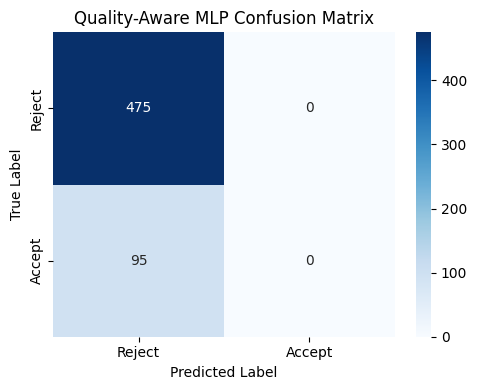

In [16]:
# -------------------------
# MLP Confusion Matrix
# -------------------------

cm = confusion_matrix(
    mlp_result["y_true"],
    mlp_result["y_pred"],
)

plt.figure(figsize=(5,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Reject", "Accept"],
    yticklabels=["Reject", "Accept"],
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Quality-Aware MLP Confusion Matrix")

plt.tight_layout()

plt.savefig(
    "figures/tinyface_mlp_confusion_matrix.png",
    dpi=600,
    bbox_inches="tight",
)

plt.show()

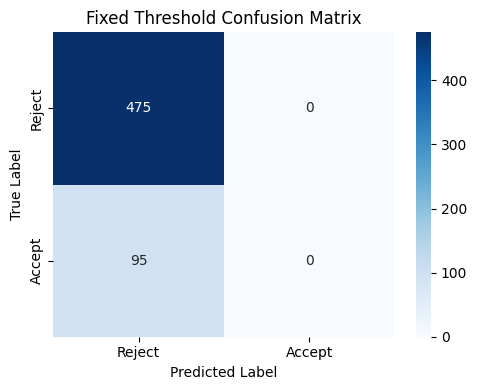

In [17]:
# -------------------------
# Threshold Confusion Matrix
# -------------------------

cm = confusion_matrix(
    threshold_result["y_true"],
    threshold_result["y_pred"],
)

plt.figure(figsize=(5,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Reject", "Accept"],
    yticklabels=["Reject", "Accept"],
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Fixed Threshold Confusion Matrix")

plt.tight_layout()

plt.savefig(
    "figures/tinyface_threshold_confusion_matrix.png",
    dpi=600,
    bbox_inches="tight",
)

plt.show()

In [18]:
df = pd.read_csv(TINYFACE_CSV)

print("\nLabel Counts")
print(df["label"].value_counts())

print("\nOverall Similarity")
print(df["best_similarity"].describe())

print("\nOverall Margin")
print(df["margin"].describe())

print("\nPositive Similarities")
print(df[df["label"] == 1]["best_similarity"].describe())

print("\nNegative Similarities")
print(df[df["label"] == 0]["best_similarity"].describe())

print("\nPositive Margins")
print(df[df["label"] == 1]["margin"].describe())

print("\nNegative Margins")
print(df[df["label"] == 0]["margin"].describe())

print("\nPredicted Accepts (MLP)")
print(mlp_result["y_pred"].sum())


Label Counts
label
0    475
1     95
Name: count, dtype: int64

Overall Similarity
count    570.000000
mean       0.043664
std        0.073824
min       -0.129730
25%       -0.003198
50%        0.035309
75%        0.077507
max        0.391348
Name: best_similarity, dtype: float64

Overall Margin
count    570.000000
mean       0.038789
std        0.040674
min        0.000297
25%        0.006758
50%        0.025404
75%        0.051486
max        0.175305
Name: margin, dtype: float64

Positive Similarities
count    95.000000
mean      0.110307
std       0.090549
min      -0.063376
25%       0.036751
50%       0.086620
75%       0.172274
max       0.347532
Name: best_similarity, dtype: float64

Negative Similarities
count    475.000000
mean       0.030335
std        0.062034
min       -0.129730
25%       -0.008787
50%        0.028452
75%        0.066780
max        0.391348
Name: best_similarity, dtype: float64

Positive Margins
count    95.000000
mean      0.038789
std       0.040854
min 

In [19]:
print("\nActual Accepts")
print(df["label"].sum())


Actual Accepts
95


In [20]:
print(df[["quality_score", "best_similarity", "margin"]].describe())

       quality_score  best_similarity      margin
count     570.000000       570.000000  570.000000
mean       18.465148         0.043664    0.038789
std         2.582389         0.073824    0.040674
min        14.313741        -0.129730    0.000297
25%        16.682201        -0.003198    0.006758
50%        18.100471         0.035309    0.025404
75%        19.734016         0.077507    0.051486
max        26.320620         0.391348    0.175305
